In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

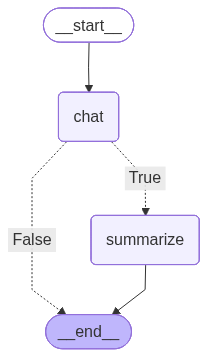

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [ ]:
# # 1st round of conversation
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='40ccd042-0fe4-4810-8638-ea6fac9e1b45')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a branch of physics that deals with the behavior of very smal


In [14]:
# # 2nd round of conversation
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='40ccd042-0fe4-4810-8638-ea6fac9e1b45'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of very small particles, such as atoms and subatomic particles, at the quantum level. It is a theoretical framework that describes the behavior of these particles in terms of probability waves and uncertainty, rather than classical mechanics.\n\nOne of the key principles of quantum physics is superposition, which states that particles can exist in multiple states at the same time until they are observed or measured. Another important concept is entanglement, where particles become connected in such a way that the state of one particle is instantly correlated with the state of another, regardless of the distance between them.\n\nQuantum physics has led to many groundbreaking theories and technologies, such as quantum cryptography, quantum computing, and quantum teleportation

In [ ]:
# 3rd round of conversation - this should trigger summarization
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='40ccd042-0fe4-4810-8638-ea6fac9e1b45'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of very small particles, such as atoms and subatomic particles, at the quantum level. It is a theoretical framework that describes the behavior of these particles in terms of probability waves and uncertainty, rather than classical mechanics.\n\nOne of the key principles of quantum physics is superposition, which states that particles can exist in multiple states at the same time until they are observed or measured. Another important concept is entanglement, where particles become connected in such a way that the state of one particle is instantly correlated with the state of another, regardless of the distance between them.\n\nQuantum physics has led to many groundbreaking theories and technologies, such as quantum cryptography, quantum computing, and quantum teleportation

In [16]:
#
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='40ccd042-0fe4-4810-8638-ea6fac9e1b45'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of very small particles, such as atoms and subatomic particles, at the quantum level. It is a theoretical framework that describes the behavior of these particles in terms of probability waves and uncertainty, rather than classical mechanics.\n\nOne of the key principles of quantum physics is superposition, which states that particles can exist in multiple states at the same time until they are observed or measured. Another important concept is entanglement, where particles become connected in such a way that the state of one particle is instantly correlated with the state of another, regardless of the distance between them.\n\nQuantum physics has led to many groundbreaking theories and technologies, such as quantum cryptography, quantum computing, and quantum teleportation